In [3]:
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series >= lower) & (series <= upper)]

Max time model:
Metamodel: esb, Model: result0_1000000, Time: 371.6840 s

Max memory model:
Metamodel: esb, Model: result0_1000000, Memory: 5.3797 GB


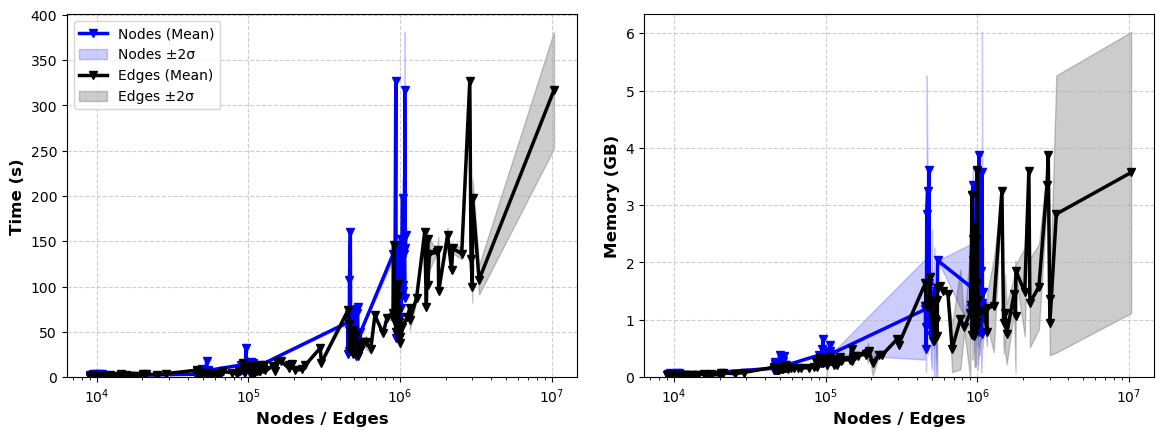

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os

# ---- Helper (you already use it, keeping it here for completeness) ----
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return series[(series >= q1 - 1.5 * iqr) & (series <= q3 + 1.5 * iqr)]

# Load all run files from subfolders (one folder per metamodel)
run_files = glob.glob('../results/RQ2Models/**/run_*.csv', recursive=True)

dfs = []
for f in run_files:
    df = pd.read_csv(f)

    # Extract metamodel name from folder
    metamodel = os.path.basename(os.path.dirname(f))
    df['metamodel'] = metamodel

    # Convert units
    df['time'] = df['time'] / 1000.0          # ms → seconds
    df['mem'] = df['mem'] / (1024 * 1024)     # KB → GB

    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

# ---- PRINT MAX RESULTS ----
# Max time
idx_time = combined_df['time'].idxmax()
row_time = combined_df.loc[idx_time]
print("Max time model:")
print(f"Metamodel: {row_time['metamodel']}, Model: {row_time['model']}, Time: {row_time['time']:.4f} s")

# Max memory
idx_mem = combined_df['mem'].idxmax()
row_mem = combined_df.loc[idx_mem]
print("\nMax memory model:")
print(f"Metamodel: {row_mem['metamodel']}, Model: {row_mem['model']}, Memory: {row_mem['mem']:.4f} GB")

# ---- PLOTTING ----
props = ['nodes', 'edges']
colors = {'nodes': 'blue', 'edges': 'black'}
g = 2  # number of std deviations

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('')

# ---- TIME PLOT ----
for prop in props:
    grouped = combined_df.groupby(prop)['time']
    mean = grouped.apply(lambda s: remove_outliers(s).mean())
    std = grouped.apply(lambda s: remove_outliers(s).std())
    lower = mean - g * std
    upper = mean + g * std

    axes[0].plot(
        mean.index, mean.values,
        color=colors[prop], linewidth=2.5, marker='v',
        label=f'{prop.capitalize()} (Mean)'
    )
    axes[0].fill_between(
        mean.index, lower, upper,
        color=colors[prop], alpha=0.2,
        label=f'{prop.capitalize()} ±{g}σ'
    )

axes[0].set_xlabel("Nodes / Edges", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Time (s)", fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_ylim(bottom=0)
axes[0].legend(fontsize=10, frameon=True)
axes[0].set_xscale('log')

# ---- MEMORY PLOT ----
for prop in props:
    grouped = combined_df.groupby(prop)['mem']
    mean = grouped.apply(lambda s: remove_outliers(s).mean())
    std = grouped.apply(lambda s: remove_outliers(s).std())
    lower = mean - g * std
    upper = mean + g * std

    axes[1].plot(
        mean.index, mean.values,
        color=colors[prop], linewidth=2.5, marker='v',
        label=f'{prop.capitalize()} (Mean)'
    )
    axes[1].fill_between(
        mean.index, lower, upper,
        color=colors[prop], alpha=0.2,
        label=f'{prop.capitalize()} ±{g}σ'
    )

axes[1].set_xlabel("Nodes / Edges", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Memory (GB)", fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_ylim(bottom=0)
axes[1].set_xscale('log')

plt.tight_layout(pad=2)
plt.savefig("img/RQ2genmodels.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [5]:
import pandas as pd
import glob
import os

# ---- Helper ----
def remove_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return series[(series >= q1 - 1.5 * iqr) & (series <= q3 + 1.5 * iqr)]

# ---- LOAD DATA ----
run_files = glob.glob('../results/RQ2Models/**/run_*.csv', recursive=True)

dfs = []
for f in run_files:
    df = pd.read_csv(f)

    metamodel = os.path.basename(os.path.dirname(f))
    df['metamodel'] = metamodel

    df['time'] = df['time'] / 1000.0
    df['mem'] = df['mem'] / (1024 * 1024)

    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

print("\n================ GLOBAL STATISTICS ================\n")

for metric in ['time', 'mem']:
    s = combined_df[metric]
    print(f"--- {metric.upper()} ---")
    print(f"Mean:   {s.mean():.4f}")
    print(f"Median: {s.median():.4f}")
    print(f"Std:    {s.std():.4f}")
    print(f"Min:    {s.min():.4f}")
    print(f"Max:    {s.max():.4f}")
    print()

print("\n========== GLOBAL (OUTLIER REMOVED) ==============\n")

for metric in ['time', 'mem']:
    s = remove_outliers(combined_df[metric])
    print(f"--- {metric.upper()} ---")
    print(f"Mean:   {s.mean():.4f}")
    print(f"Median: {s.median():.4f}")
    print(f"Std:    {s.std():.4f}")
    print(f"Count:  {len(s)} (after filtering)")
    print()

# ---- PER METAMODEL ----
print("\n================ PER METAMODEL ===================\n")

grouped_meta = combined_df.groupby('metamodel')

for name, group in grouped_meta:
    print(f"\n--- {name} ---")
    print(f"Models: {len(group)}")

    for metric in ['time', 'mem']:
        s = remove_outliers(group[metric])
        print(f"{metric}: mean={s.mean():.4f}, std={s.std():.4f}, max={s.max():.4f}")

# ---- PER SIZE (NODES / EDGES) ----
print("\n================ PER SIZE ========================\n")

for prop in ['nodes', 'edges']:
    print(f"\n--- By {prop} ---")

    grouped = combined_df.groupby(prop)

    for val, group in grouped:
        time_mean = remove_outliers(group['time']).mean()
        mem_mean = remove_outliers(group['mem']).mean()

        print(f"{prop}={val}: time_mean={time_mean:.4f}s, mem_mean={mem_mean:.4f}GB")



# ---- TOP K (SLOWEST / HEAVIEST) ----
print("\n================ TOP 5 ===========================\n")

print("Top 5 slowest models:")
print(combined_df.nlargest(5, 'time')[['metamodel', 'model', 'time']])

print("\nTop 5 most memory-intensive models:") 
print(combined_df.nlargest(5, 'mem')[['metamodel', 'model', 'mem']])


================ GLOBAL STATISTICS ================

--- TIME ---
Mean:   37.7971
Median: 10.1195
Std:    54.7673
Min:    0.3540
Max:    371.6840

--- MEM ---
Mean:   0.7228
Median: 0.3086
Std:    0.8738
Min:    0.0273
Max:    5.3797


========== GLOBAL (OUTLIER REMOVED) ==============

--- TIME ---
Mean:   26.4483
Median: 8.4975
Std:    32.7219
Count:  4178 (after filtering)

--- MEM ---
Mean:   0.5788
Median: 0.2930
Std:    0.6003
Count:  4284 (after filtering)


================ PER METAMODEL ===================


--- ApplauseDsl ---
Models: 150
time: mean=21.0201, std=23.9145, max=71.9410
mem: mean=0.5892, std=0.5703, max=1.5190

--- AthenaDSL ---
Models: 150
time: mean=27.2187, std=32.2734, max=91.8800
mem: mean=0.6762, std=0.6515, max=1.8594

--- AtsDsl ---
Models: 150
time: mean=21.7991, std=24.2075, max=67.1390
mem: mean=1.0835, std=1.1935, max=3.1797

--- CoreDsl ---
Models: 150
time: mean=19.2502, std=21.7170, max=61.2270
mem: mean=0.5333, std=0.5198, max=1.4504

--- CssExtD

## Reverse Engineering

In [7]:
props = ['nodes', 'edges']

run_files = glob.glob('../results/RQ2Models-reverse/**/run_*.csv', recursive=True)

dfs = []
for f in run_files:
    df = pd.read_csv(f)

    # Extract metamodel name from folder
    metamodel = os.path.basename(os.path.dirname(f))
    df['metamodel'] = metamodel

    # Convert units
    df['time'] = df['time'] / 1000.0          # ms → seconds
    df['mem'] = df['mem'] / (1024 * 1024)     # KB → GB

    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

def compute_stats(series):
    s = remove_outliers(series)
    return pd.Series({
        'min': s.min(),
        'max': s.max(),
        'mean': s.mean(),
        'std': s.std()
    })

# ---- TIME STATS ----
print("\n==== TIME STATS (seconds) ====")
for prop in props:
    stats = combined_df.groupby(prop)['time'].apply(compute_stats)
    print(f"\n--- Grouped by {prop} ---")
    print(stats)

# ---- MEMORY STATS ----
print("\n==== MEMORY STATS (GB) ====")
for prop in props:
    stats = combined_df.groupby(prop)['mem'].apply(compute_stats)
    print(f"\n--- Grouped by {prop} ---")
    print(stats)


==== TIME STATS (seconds) ====

--- Grouped by nodes ---
nodes        
100126   min      11.145000
         max      11.224000
         mean     11.178103
         std       0.023727
1000658  min     121.329000
         max     123.664000
         mean    122.402931
         std       0.705331
4357774  min     460.535000
         max     813.102000
         mean    643.469833
         std     100.050887
Name: time, dtype: float64

--- Grouped by edges ---
edges         
262258    min      11.145000
          max      11.224000
          mean     11.178103
          std       0.023727
2672591   min     121.329000
          max     123.664000
          mean    122.402931
          std       0.705331
11478915  min     460.535000
          max     813.102000
          mean    643.469833
          std     100.050887
Name: time, dtype: float64

==== MEMORY STATS (GB) ====

--- Grouped by nodes ---
nodes        
100126   min     0.524621
         max     0.546877
         mean    0.537954
  